# BAMv3 실험: 노이즈→노이즈 학습

**Ultra-low SNR 환경을 위한 Robust Feature Learning**
- Self-supervised 학습 방식
- 다양한 SNR에서 일관된 패턴 학습
- 병목 효과로 랜덤 노이즈 제거
- 노이즈 범위 줄임(5~-5db)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAMv3
import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)


/home/gwon9906/LoRa-bam-reconstruction/utils/my_lora_utils.py


In [2]:
import numpy as np
from scipy.signal import stft, istft

STFT_PARAMS = {
    "nperseg": 128,
    "noverlap": 64,   # hop = 64
    "nfft": 512,
    "window": "hann",
}


def _make_blend_weight(f_shifted, bw, guard_ratio=1.25, taper_bins=8, dc_notch_hz=0.0):
    """
    w: core에서는 1, guard 밖에서는 0, 경계는 완만한 ramp
    """
    bw_guard = bw * guard_ratio
    core_mask  = (f_shifted >= -bw/2) & (f_shifted < bw/2)
    guard_mask = (f_shifted >= -bw_guard/2) & (f_shifted < bw_guard/2)

    idx_core  = np.where(core_mask)[0]
    idx_guard = np.where(guard_mask)[0]
    if len(idx_guard) == 0:
        raise ValueError("guard_mask is empty. Check bw/fs/nfft/guard_ratio.")

    # 기본 w=0
    w = np.zeros_like(f_shifted, dtype=np.float32)

    # guard 구간은 일단 1로 채워두고, 경계 taper로 깎는 형태로 만들자
    lo_g, hi_g = idx_guard[0], idx_guard[-1]
    w[lo_g:hi_g+1] = 1.0

    # guard의 바깥 경계 taper (1 -> 0)
    if taper_bins > 0:
        # left
        l0 = max(0, lo_g - taper_bins)
        if l0 < lo_g:
            w[l0:lo_g] = np.linspace(0.0, 1.0, lo_g - l0, endpoint=False, dtype=np.float32)
        # right
        h1 = min(len(w), hi_g + taper_bins + 1)
        if hi_g + 1 < h1:
            w[hi_g+1:h1] = np.linspace(1.0, 0.0, h1 - (hi_g+1), endpoint=False, dtype=np.float32)

    # 이제 core 밖(guard 안)은 1인 상태인데, core를 진짜 “완전 1”로 확정
    if len(idx_core) > 0:
        lo_c, hi_c = idx_core[0], idx_core[-1]
        w[lo_c:hi_c+1] = 1.0

    # DC notch: 필요하면 해당 구간은 w=0 (원본 유지 or 나중에 노치 가능)
    if dc_notch_hz and dc_notch_hz > 0:
        w[np.abs(f_shifted) < dc_notch_hz] = 0.0

    return w, core_mask, guard_mask


def generate_complex_spectrogram(
    iq_signal, fs, bw=125_000,
    guard_ratio=1.25, taper_bins=8, dc_notch_hz=0.0,
    norm_mode="rms"
):
    nperseg  = STFT_PARAMS['nperseg']
    noverlap = STFT_PARAMS['noverlap']
    nfft     = STFT_PARAMS['nfft']
    window   = STFT_PARAMS['window']

    f, t, Zxx = stft(
        iq_signal, fs=fs, window=window,
        nperseg=nperseg, noverlap=noverlap, nfft=nfft,
        boundary=None, padded=False, return_onesided=False
    )

    f_shifted = np.fft.fftshift(f)
    Zs_orig   = np.fft.fftshift(Zxx, axes=0).astype(np.complex64)  # ✅ full shifted 원본 저장
    original_shape = Zs_orig.shape

    # ✅ 블렌딩 weight + 마스크들
    w, core_mask, in_mask = _make_blend_weight(
        f_shifted, bw, guard_ratio=guard_ratio, taper_bins=taper_bins, dc_notch_hz=dc_notch_hz
    )

 
    Z_in = Zs_orig[core_mask, :]
    freq_indices = np.where(core_mask)[0]

    # ✅ 복원에서 '교체할 위치'도 core_mask로 지정해야 input_dim과 shape가 일치함
    freq_mask_for_model = core_mask


    # ✅ complex 공통 스케일 정규화
    mag = np.abs(Z_in)
    if norm_mode == "max":
        scale = float(np.max(mag) + 1e-12)
    else:  # rms
        scale = float(np.sqrt(np.mean(mag**2)) + 1e-12)

    Z_norm = (Z_in / scale).astype(np.complex64)

    real_flat = Z_norm.real.astype(np.float32).flatten()
    imag_flat = Z_norm.imag.astype(np.float32).flatten()
    combined_flat = np.concatenate([real_flat, imag_flat], axis=0)

    norm_params = {
    'shape': Z_in.shape,
    'original_shape': original_shape,

    # ✅ 여기! freq_mask를 core로
    'freq_mask': freq_mask_for_model,
    'freq_indices': freq_indices,

    # 블렌딩/복원 안정용은 따로 저장 (guard 기반)
    'blend_w': w.astype(np.float32),
    'Zs_orig': Zs_orig,

    'core_mask': core_mask,        # (있어도 됨)
    'guard_mask': in_mask,         # (원하면 저장)
    'stft_params': STFT_PARAMS.copy(),
    'orig_len': len(iq_signal),
    'fs': fs,
    'scale': scale,
}


    return combined_flat, norm_params


In [ ]:
def reconstruct_iq_from_spectrogram(restored_flat, norm_params):
    fs = norm_params['fs']
    stft_params = norm_params['stft_params']

    F_in, T = norm_params['shape']
    mid = restored_flat.shape[0] // 2

    real_norm = restored_flat[:mid].reshape(F_in, T).astype(np.float32)
    imag_norm = restored_flat[mid:].reshape(F_in, T).astype(np.float32)
    Z_norm = (real_norm + 1j * imag_norm).astype(np.complex64)

    scale = float(norm_params.get('scale', 1.0))
    Z_in_restored = (Z_norm * scale).astype(np.complex64)

    in_mask = norm_params['freq_mask']
    w = norm_params['blend_w'].astype(np.float32)
    Zs_orig = norm_params['Zs_orig']  # full shifted original

    # restored_full = 원본 복사 후 inside만 교체
    Zs_restored = Zs_orig.copy()
    Zs_restored[in_mask, :] = Z_in_restored

    Zs_final = (w[:, None] * Zs_restored) + ((1.0 - w)[:, None] * Zs_orig)

    dc_notch_hz = float(norm_params.get('dc_notch_hz', 0.0))
    if dc_notch_hz > 0:
        # f_shifted를 저장 안 했으니, w==0인 DC 구간이 원본 유지가 됨.
        # 진짜로 0으로 만들고 싶다면 generate에서 dc_mask도 저장해두고 여기서 0처리.
        pass

    Z_unshift = np.fft.ifftshift(Zs_final, axes=0)

    _, iq_restored = istft(
        Z_unshift,
        fs=fs,
        window=stft_params['window'],
        nperseg=stft_params['nperseg'],
        noverlap=stft_params['noverlap'],
        nfft=stft_params['nfft'],
        input_onesided=False,
        boundary=None,
    )

    target_len = norm_params.get('orig_len', len(iq_restored))
    if len(iq_restored) > target_len:
        iq_restored = iq_restored[:target_len]
    elif len(iq_restored) < target_len:
        iq_restored = np.pad(iq_restored, (0, target_len - len(iq_restored)), mode='constant')

    return iq_restored


In [4]:
# LoRa 파라미터 설정
sf = 9
bw = 250_000  # 250 kHz
OSF = 4
fs = int(bw * OSF)  # 1 MHz

print(f"SF = {sf}, BW = {bw/1e3:.1f} kHz, fs = {fs/1e6:.3f} MHz")

# LoRa 인스턴스 생성 (on-the-fly 노이즈 추가용)
lora = LoRa(sf=sf, bw=bw, OSF=OSF)
fs = lora.fs   # = bw * OSF


SF = 9, BW = 250.0 kHz, fs = 1.000 MHz


In [5]:
########################################
##  1. 클린 IQ 데이터 로드            ##
########################################

base_dir = "dataset_v3_sf9_bw250k"
iq_dir = os.path.join(base_dir, "clean_iq")

print("Loading clean IQ data...")
iq_files = sorted(glob.glob(os.path.join(iq_dir, "*.npy")))
print(f"Found {len(iq_files)} clean IQ files")

# 클린 IQ 로드
iq_data_list = []
for f in iq_files:
    x_clean = np.load(f)  # complex IQ
    iq_data_list.append(x_clean)

X_clean_iq = np.array(iq_data_list)
print(f"Clean IQ shape: {X_clean_iq.shape}, dtype: {X_clean_iq.dtype}")


Loading clean IQ data...
Found 512 clean IQ files
Clean IQ shape: (512, 2048), dtype: complex64


In [ ]:
########################################
##  2. 데이터 증강 함수 정의          ##
########################################

# SNR 범위 설정 (SNR에 집중)
SNR_MIN = -5
SNR_MAX = 5
AUGMENT_FACTOR = 30  # 각 클린 IQ를 30배로 증강

def iq_to_flat_with_reuse(iq_signal, norm_params):
    """
    generate_complex_spectrogram에서 만든 norm_params(특히 freq_mask, scale)를 재사용해서
    같은 좌표계로 flat 벡터를 만든다.
    """
    nperseg  = norm_params['stft_params']['nperseg']
    noverlap = norm_params['stft_params']['noverlap']
    nfft     = norm_params['stft_params']['nfft']
    window   = norm_params['stft_params']['window']
    fs       = norm_params['fs']

    from scipy.signal import stft
    f, t, Zxx = stft(
        iq_signal, fs=fs, window=window,
        nperseg=nperseg, noverlap=noverlap, nfft=nfft,
        boundary=None, padded=False, return_onesided=False
    )

    f_shifted = np.fft.fftshift(f)
    Zs        = np.fft.fftshift(Zxx, axes=0).astype(np.complex64)

    in_mask = norm_params['freq_mask']
    Z_in = Zs[in_mask, :]  # (F_in,T)

    scale = float(norm_params['scale'])
    Z_norm = (Z_in / scale).astype(np.complex64)

    real_flat = Z_norm.real.astype(np.float32).flatten()
    imag_flat = Z_norm.imag.astype(np.float32).flatten()
    return np.concatenate([real_flat, imag_flat], axis=0)

def augment_dataset(X_clean_iq, augment_factor=30):
    print(f"\nGenerating {len(X_clean_iq)} × {augment_factor} = {len(X_clean_iq) * augment_factor} augmented samples...")

    X_noisy_flat_list = []
    X_clean_flat_list = []
    norm_params_list  = []

    for clean_iq in X_clean_iq:
        for _ in range(augment_factor):
            snr = np.random.randint(SNR_MIN, SNR_MAX + 1)
            noisy_iq = lora.awgn_iq(clean_iq, snr)

            # 1) noisy로 norm_params를 먼저 만들고 (mask/scale 확정)
            noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)

            # 2) clean은 같은 mask/scale로 flat 생성 (좌표계 동일)
            clean_flat = iq_to_flat_with_reuse(clean_iq, norm_params)

            X_noisy_flat_list.append(noisy_flat)
            X_clean_flat_list.append(clean_flat)
            norm_params_list.append(norm_params)

    X_noisy_flat = np.array(X_noisy_flat_list, dtype=np.float32)
    X_clean_flat = np.array(X_clean_flat_list, dtype=np.float32)

    print(f"Augmented dataset shape: {X_noisy_flat.shape} (noisy), {X_clean_flat.shape} (clean target)")
    return X_noisy_flat, X_clean_flat, norm_params_list



In [7]:
########################################
##  3. 모델 아키텍처 설정             ##
########################################

# Complex 스펙트로그램 shape 확인을 위한 테스트 (1개만)
test_spec_flat, test_params = generate_complex_spectrogram(X_clean_iq[0], fs, bw)
input_dim = test_spec_flat.shape[0]  # Real + Imag 통합 (2배)

# 점진적 압축: 7936 → 4096 → 3072 → 2048
layers = [input_dim, 4096, 2048, 512]

print(f"Complex spectrogram shape: {test_params['shape']}")
print(f"Input dim (Real+Imag): {input_dim}")
print(f"Model architecture: {' → '.join(map(str, layers))}")
print(f"Compression ratio: {input_dim / layers[-1]:.1f}x")
print(f"Layers: {len(layers)-1} BAM layers (더 부드러운 압축)")


Complex spectrogram shape: (128, 31)
Input dim (Real+Imag): 7936
Model architecture: 7936 → 4096 → 2048 → 512
Compression ratio: 15.5x
Layers: 3 BAM layers (더 부드러운 압축)



=== Training BAMv3 Model (Complex Spectrogram) ===
Architecture: 7936 → 4096 → 2048 → 512
Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)

=== Starting Training with On-the-fly Complex Augmentation ===
Base samples: 512
Augmentation factor: 30x
Total per epoch: 15360

Epoch 1/30

Generating 512 × 30 = 15360 augmented samples...
Augmented dataset shape: (15360, 7936) (noisy), (15360, 7936) (clean target)

--- Training Layer 1/3 ---
Epoch 1, Batch 1/240, MSE=0.306621
Epoch 1, Batch 2/240, MSE=0.298391
Epoch 1, Batch 3/240, MSE=0.310024
Epoch 1, Batch 4/240, MSE=0.308262
Epoch 1, Batch 5/240, MSE=0.317248
Epoch 1, Batch 6/240, MSE=0.307424
Epoch 1, Batch 7/240, MSE=0.316782
Epoch 1, Batch 8/240, MSE=0.307573
Epoch 1, Batch 9/240, MSE=0.304508
Epoch 1, Batch 10/240, MSE=0.311013
Epoch 1, Batch 11/240, MSE=0.303283
Epoch 1, Batch 12/240, MSE=0.319059
Epoch 1, Batch 13/240, MSE=0.304654
Epoch 1, Batch 14/240, MSE=0.305815
Epoch 1, Batch 15/240, MSE=0.303957
Epoch 1, Batch 

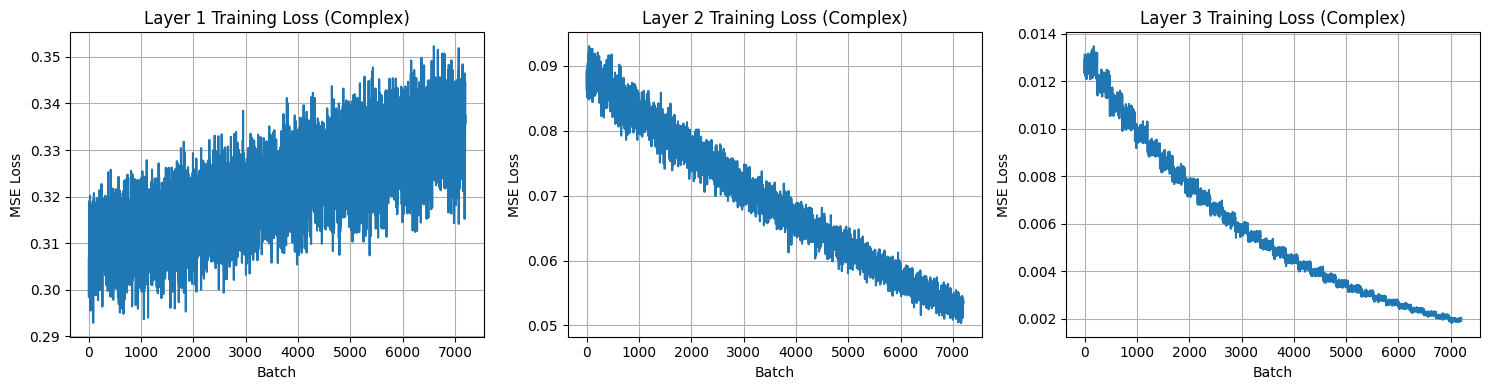

In [ ]:
########################################
##  4. BAMv3 Complex 30배 증강 학습  ##
########################################

print(f"\n=== Training BAMv3 Model (Complex Spectrogram) ===")
print(f"Architecture: {' → '.join(map(str, layers))}")
print(f"Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)")

# BAMv3 모델 생성 (학습률 조정: 3-layer BAM에 적합한 lr)
model = MultiBAMv3(layers_dims=layers, eta=1e-5, max_update_norm=1.0, weight_decay=1e-4)

# 학습 플래그
TRAIN = True # 테스트 전에는 False

if TRAIN:
    print("\n=== Starting Training with On-the-fly Complex Augmentation ===")
    print(f"Base samples: {len(X_clean_iq)}")
    print(f"Augmentation factor: {AUGMENT_FACTOR}x")
    print(f"Total per epoch: {len(X_clean_iq) * AUGMENT_FACTOR}")
    
    # 학습 파라미터
    num_epochs = 30
    batch_size = 64
    
    all_layer_losses = [[] for _ in range(len(layers)-1)]
    
    # 매 epoch마다 새로운 노이즈로 증강
    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*60}")
        
        # 30배 증강된 Complex 데이터 생성 (매 epoch마다 다른 노이즈!)
        X_noisy, X_clean, _ = augment_dataset(X_clean_iq, AUGMENT_FACTOR)
        layer_losses = model.train(X_noisy, X_clean, num_epochs=1, batch_size=batch_size)

        
        # Loss 기록
        for i, losses in enumerate(layer_losses):
            all_layer_losses[i].extend(losses)
    
    print("\n=== Training Complete ===")
    
    # Loss 플롯 (각 layer별)
    fig, axes = plt.subplots(1, len(all_layer_losses), figsize=(15, 4))
    if len(all_layer_losses) == 1:
        axes = [axes]
    
    for i, losses in enumerate(all_layer_losses):
        axes[i].plot(losses)
        axes[i].set_xlabel('Batch')
        axes[i].set_ylabel('MSE Loss')
        axes[i].set_title(f'Layer {i+1} Training Loss (Complex)')
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nTraining skipped (TRAIN=False)")


In [9]:
########################################
##  5. 모델 저장                     ##
########################################

import torch

if TRAIN:
    # 모델 저장 폴더
    weight_folder = "weights_bamv3_complex"
    os.makedirs(weight_folder, exist_ok=True)
    
    # 각 layer의 weight 저장
    for i, bam in enumerate(model.bams):
        weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
        np.save(weight_path, bam.W.cpu().numpy())
        print(f"✅ Layer {i} weights saved to: {weight_path}")
    
    # 아키텍처 정보 저장
    config = {
        'layers': layers,
        'eta': 5e-4,
        'sf': sf,
        'bw': bw,
        'fs': fs,
        'mode': 'complex'  # Complex 방식 표시
    }
    config_path = os.path.join(weight_folder, "model_config.npy")
    np.save(config_path, config)
    print(f"✅ Config saved to: {config_path}")

print("\n=== How to Load Model ===")
print("""
# 모델 로드 예시:
config = np.load('weights_bamv3_complex/model_config.npy', allow_pickle=True).item()
model = MultiBAMv3(layers_dims=config['layers'], eta=config['eta'])
for i, bam in enumerate(model.bams):
    bam.W = torch.tensor(np.load(f'weights_bamv3_complex/weights_layer_{i}.npy'))
""")


✅ Layer 0 weights saved to: weights_bamv3_complex/weights_layer_0.npy
✅ Layer 1 weights saved to: weights_bamv3_complex/weights_layer_1.npy
✅ Layer 2 weights saved to: weights_bamv3_complex/weights_layer_2.npy
✅ Config saved to: weights_bamv3_complex/model_config.npy

=== How to Load Model ===

# 모델 로드 예시:
config = np.load('weights_bamv3_complex/model_config.npy', allow_pickle=True).item()
model = MultiBAMv3(layers_dims=config['layers'], eta=config['eta'])
for i, bam in enumerate(model.bams):
    bam.W = torch.tensor(np.load(f'weights_bamv3_complex/weights_layer_{i}.npy'))



In [10]:
########################################
##  5-1. 학습된 모델 로드 (TRAIN=False일 때)  ##
########################################

import torch

# TRAIN=False인 경우에만 저장된 모델 로드
if not TRAIN:
    weight_folder = "weights_bamv3_complex"
    
    # Config 파일이 존재하는지 확인
    config_path = os.path.join(weight_folder, "model_config.npy")
    
    if os.path.exists(config_path):
        print(f"\n=== Loading Pre-trained Model ===")
        
        # Config 로드
        config = np.load(config_path, allow_pickle=True).item()
        print(f"Loaded config: {config}")
        
        # 아키텍처가 동일한지 확인
        if config['layers'] == layers:
            # 각 layer의 weight 로드
            for i, bam in enumerate(model.bams):
                weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
                if os.path.exists(weight_path):
                    loaded_weight = np.load(weight_path)
                    # 🔧 디바이스 지정 추가! (CPU/CUDA 자동 감지)
                    bam.W = torch.tensor(loaded_weight, dtype=torch.float32).to(bam.device)
                    print(f"✅ Layer {i} weights loaded from: {weight_path} (device: {bam.device})")
                else:
                    print(f"❌ Warning: {weight_path} not found!")
            
            print(f"✅ Model successfully loaded from {weight_folder}")
        else:
            print(f"❌ Warning: Architecture mismatch!")
            print(f"   Current: {layers}")
            print(f"   Saved:   {config['layers']}")
    else:
        print(f"❌ Warning: No pre-trained model found in {weight_folder}")
        print(f"   Please set TRAIN=True to train a new model first.")
else:
    print("\n=== Using Newly Trained Model ===")
    print("Model weights from training will be used.")



=== Using Newly Trained Model ===
Model weights from training will be used.



=== Testing Complex Reconstruction (NEW PIPELINE) ===
Test symbol: 215, SNR: -10 dB
✅ IQ reconstructed: len=2048

=== Debug (NEW norm) ===
scale=3.980354e-01, norm_mode=None
Noisy flat:    min=-3.2235, max=3.1561, mean=-0.0005
Restored flat: min=-0.0000, max=0.0000, mean=-0.0000
Flat MSE(noisy vs restored)=0.499996


/tmp/ipykernel_37714/2506460019.py:35: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


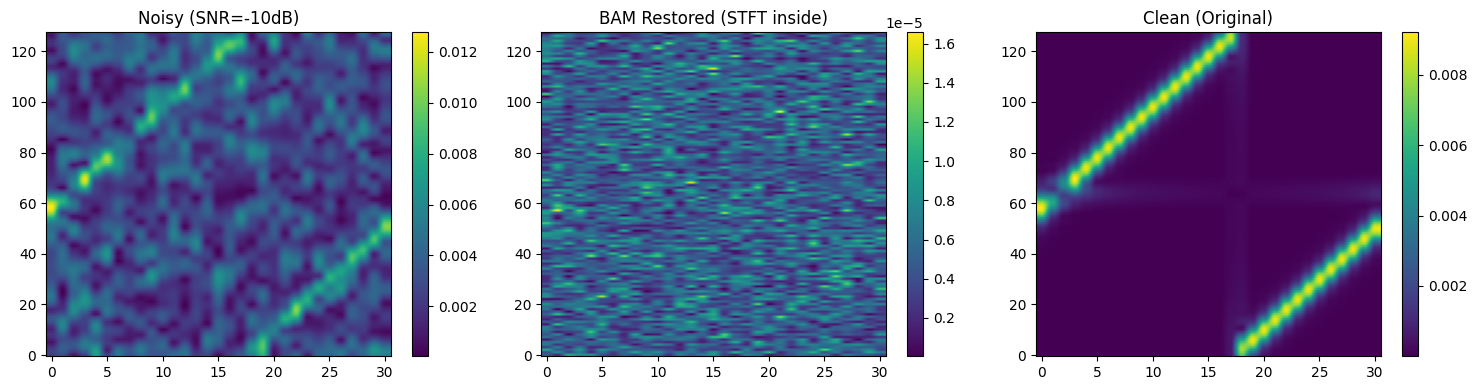


=== Spectrogram Magnitude Check (same mask) ===
Noisy:    min=0.0000, max=0.0128
Restored: min=0.0000, max=0.0000
Clean:    min=0.0000, max=0.0092


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, spectrogram

def flat_to_Zin(restored_flat, norm_params):
    """restored_flat (real+imag) -> Z_in_restored (complex, scale 역적용)"""
    F_in, T = norm_params['shape']
    mid = len(restored_flat) // 2
    real_norm = restored_flat[:mid].reshape(F_in, T).astype(np.float32)
    imag_norm = restored_flat[mid:].reshape(F_in, T).astype(np.float32)
    Z_norm = (real_norm + 1j * imag_norm).astype(np.complex64)

    scale = float(norm_params.get('scale', 1.0))
    return (Z_norm * scale).astype(np.complex64)


########################################
##  6. 테스트: Complex 복원 및 IQ 재구성  ##
########################################

test_symbol = 215
test_snr = -10

print(f"\n=== Testing Complex Reconstruction (NEW PIPELINE) ===")
print(f"Test symbol: {test_symbol}, SNR: {test_snr} dB")

clean_iq = X_clean_iq[test_symbol]
noisy_iq = lora.awgn_iq(clean_iq, test_snr)

# 1) noisy -> flat + meta
noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)

# 2) BAM compress/decompress
compressed = model.compress(noisy_flat.reshape(1, -1))
restored_flat = model.decompress(compressed).flatten()

# 3) flat -> restored STFT(inside/core) 복원(시각화용)
Zxx_restored = flat_to_Zin(restored_flat, norm_params)

# 4) IQ 복원 (최신 reconstruct 함수 시그니처)
iq_reconstructed = reconstruct_iq_from_spectrogram(restored_flat, norm_params)
print(f"✅ IQ reconstructed: len={len(iq_reconstructed)}")

# 5) Debug
print("\n=== Debug (NEW norm) ===")
print(f"scale={norm_params['scale']:.6e}, norm_mode={norm_params.get('norm_mode')}")
print(f"Noisy flat:    min={noisy_flat.min():.4f}, max={noisy_flat.max():.4f}, mean={noisy_flat.mean():.4f}")
print(f"Restored flat: min={restored_flat.min():.4f}, max={restored_flat.max():.4f}, mean={restored_flat.mean():.4f}")
print(f"Flat MSE(noisy vs restored)={np.mean((noisy_flat-restored_flat)**2):.6f}")

# 6) 스펙트로그램 비교 (동일 STFT 파라미터 + '모델 mask'에 맞춰 크롭)
#    - noisy/clean은 STFT 후 shift하고, norm_params['freq_mask']로 동일 영역만 뽑아 비교
mask_used = norm_params['freq_mask']  # (F,) shifted 기준, 지금 모델이 다루는 대역(core or guard)

# noisy full STFT
f_n, t_n, Zxx_noisy_full = spectrogram(noisy_iq, fs,
                                       window='hann', nperseg=STFT_PARAMS['nperseg'],
                                       noverlap=STFT_PARAMS['noverlap'],
                                       nfft=STFT_PARAMS['nfft'],
                                       mode='complex', return_onesided=False)
f_n = np.fft.fftshift(f_n)
Zxx_noisy_full = np.fft.fftshift(Zxx_noisy_full, axes=0)
Zxx_noisy = Zxx_noisy_full[mask_used, :]

# clean full STFT
f_c, t_c, Zxx_clean_full = spectrogram(clean_iq, fs,
                                       window='hann', nperseg=STFT_PARAMS['nperseg'],
                                       noverlap=STFT_PARAMS['noverlap'],
                                       nfft=STFT_PARAMS['nfft'],
                                       mode='complex', return_onesided=False)
f_c = np.fft.fftshift(f_c)
Zxx_clean_full = np.fft.fftshift(Zxx_clean_full, axes=0)
Zxx_clean = Zxx_clean_full[mask_used, :]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(np.abs(Zxx_noisy), aspect='auto', origin='lower')
axes[0].set_title(f'Noisy (SNR={test_snr}dB)')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(np.abs(Zxx_restored), aspect='auto', origin='lower')
axes[1].set_title('BAM Restored (STFT inside)')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(np.abs(Zxx_clean), aspect='auto', origin='lower')
axes[2].set_title('Clean (Original)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print("\n=== Spectrogram Magnitude Check (same mask) ===")
print(f"Noisy:    min={np.abs(Zxx_noisy).min():.4f}, max={np.abs(Zxx_noisy).max():.4f}")
print(f"Restored: min={np.abs(Zxx_restored).min():.4f}, max={np.abs(Zxx_restored).max():.4f}")
print(f"Clean:    min={np.abs(Zxx_clean).min():.4f}, max={np.abs(Zxx_clean).max():.4f}")


In [17]:
########################################
##  7. Dechirp 및 Code 복원 평가     ##
########################################

from utils.my_lora_utils import estimate_symbol_custom

print("\n=== Dechirp Code Reconstruction Test ===")

# 🔍 IQ 신호 차이 분석
print(f"\n=== IQ Signal Analysis ===")
print(f"Clean IQ:        len={len(clean_iq)}, |mean|={np.abs(clean_iq).mean():.4f}, |max|={np.abs(clean_iq).max():.4f}")
print(f"Noisy IQ:        len={len(noisy_iq)}, |mean|={np.abs(noisy_iq).mean():.4f}, |max|={np.abs(noisy_iq).max():.4f}")
print(f"Reconstructed:   len={len(iq_reconstructed)}, |mean|={np.abs(iq_reconstructed).mean():.4f}, |max|={np.abs(iq_reconstructed).max():.4f}")

# MSE 비교 (길이 맞춤)
min_len = min(len(clean_iq), len(noisy_iq), len(iq_reconstructed))
mse_clean_noisy = np.mean(np.abs(clean_iq[:min_len] - noisy_iq[:min_len])**2)
mse_clean_recon = np.mean(np.abs(clean_iq[:min_len] - iq_reconstructed[:min_len])**2)
mse_noisy_recon = np.mean(np.abs(noisy_iq[:min_len] - iq_reconstructed[:min_len])**2)

print(f"\nMSE Comparison:")
print(f"Clean vs Noisy:        {mse_clean_noisy:.6f}")
print(f"Clean vs Reconstructed: {mse_clean_recon:.6f}")
print(f"Noisy vs Reconstructed: {mse_noisy_recon:.6f}")

# Dechirp 및 심볼 복원 테스트
print(f"\n=== Dechirp Symbol Decoding ===")

# 1. 원본 클린 신호 Dechirp
code_clean, peak_clean = estimate_symbol_custom(clean_iq, sf, fs, bw)
print(f"✅ Clean signal (len={len(clean_iq)})    → Code: {code_clean}, Peak: {peak_clean:.2f}")

# 2. 노이즈 신호 Dechirp
code_noisy, peak_noisy = estimate_symbol_custom(noisy_iq, sf, fs, bw)
print(f"⚠️  Noisy signal (len={len(noisy_iq)})    → Code: {code_noisy}, Peak: {peak_noisy:.2f}")

# 3. BAM 복원 신호 Dechirp (Resample 적용 완료!)
code_restored, peak_restored = estimate_symbol_custom(iq_reconstructed, sf, fs, bw)
print(f"🔧 Restored (len={len(iq_reconstructed)})   → Code: {code_restored}, Peak: {peak_restored:.2f}")

# 성능 평가
print(f"\n{'='*60}")
print(f"Performance Evaluation:")
print(f"{'='*60}")
print(f"Ground Truth Symbol: {test_symbol}")
print(f"Clean Decoded:       {code_clean} {'✅ CORRECT' if code_clean == test_symbol else '❌ WRONG'}")
print(f"Noisy Decoded:       {code_noisy} {'✅ CORRECT' if code_noisy == test_symbol else '❌ WRONG'}")
print(f"Restored Decoded:    {code_restored} {'✅ CORRECT' if code_restored == test_symbol else '❌ WRONG'}")
print(f"{'='*60}")

# Peak 비교
print(f"\nPeak Comparison:")
print(f"Clean Peak:    {peak_clean:.2f}")
print(f"Noisy Peak:    {peak_noisy:.2f} ({peak_noisy/peak_clean*100:.1f}% of clean)")
print(f"Restored Peak: {peak_restored:.2f} ({peak_restored/peak_clean*100:.1f}% of clean)")

if code_restored == test_symbol:
    print(f"\n✅ SUCCESS: BAMv3_huber successfully restored the correct symbol!")
else:
    print(f"\n❌ FAILURE: BAMv3_huber failed to restore the correct symbol")



=== Dechirp Code Reconstruction Test ===

=== IQ Signal Analysis ===
Clean IQ:        len=2048, |mean|=1.0000, |max|=1.0000
Noisy IQ:        len=2048, |mean|=2.9203, |max|=9.2089
Reconstructed:   len=2048, |mean|=2.6777, |max|=277.7107

MSE Comparison:
Clean vs Noisy:        9.920018
Clean vs Reconstructed: 52.432049
Noisy vs Reconstructed: 46.702026

=== Dechirp Symbol Decoding ===
✅ Clean signal (len=2048)    → Code: 42, Peak: 4194303.99
⚠️  Noisy signal (len=2048)    → Code: 42, Peak: 3531682.99
🔧 Restored (len=2048)   → Code: 146, Peak: 641426.45

Performance Evaluation:
Ground Truth Symbol: 42
Clean Decoded:       42 ✅ CORRECT
Noisy Decoded:       42 ✅ CORRECT
Restored Decoded:    146 ❌ WRONG

Peak Comparison:
Clean Peak:    4194303.99
Noisy Peak:    3531682.99 (84.2% of clean)
Restored Peak: 641426.45 (15.3% of clean)

❌ FAILURE: BAMv3_huber failed to restore the correct symbol



📊 QUANTITATIVE PERFORMANCE EVALUATION (Baseline vs BAM)

🧪 Testing with 1000 samples at each SNR level...
SNR levels: [-30, -25, -20, -15, -10, -5] dB


──────────────────────────────────────────────────────────────────────
Testing SNR = -30 dB
──────────────────────────────────────────────────────────────────────


/tmp/ipykernel_37714/2506460019.py:35: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


  ✓ Valid samples : 1000/1000  (errors=0)
  ✓ Baseline Acc  : 2.2% | MicroF1: 2.2%
  ✓ BAM Acc       : 0.0% | MicroF1: 0.0%

──────────────────────────────────────────────────────────────────────
Testing SNR = -25 dB
──────────────────────────────────────────────────────────────────────


/tmp/ipykernel_37714/2506460019.py:35: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


  ✓ Valid samples : 1000/1000  (errors=0)
  ✓ Baseline Acc  : 18.5% | MicroF1: 18.5%
  ✓ BAM Acc       : 0.0% | MicroF1: 0.0%

──────────────────────────────────────────────────────────────────────
Testing SNR = -20 dB
──────────────────────────────────────────────────────────────────────


...

  ✓ Valid samples : 1000/1000  (errors=0)
  ✓ Baseline Acc  : 100.0% | MicroF1: 100.0%
  ✓ BAM Acc       : 0.1% | MicroF1: 0.1%

──────────────────────────────────────────────────────────────────────
Testing SNR = -10 dB
──────────────────────────────────────────────────────────────────────


/tmp/ipykernel_37714/2506460019.py:35: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


  ✓ Valid samples : 1000/1000  (errors=0)
  ✓ Baseline Acc  : 100.0% | MicroF1: 100.0%
  ✓ BAM Acc       : 0.1% | MicroF1: 0.1%

──────────────────────────────────────────────────────────────────────
Testing SNR = -5 dB
──────────────────────────────────────────────────────────────────────


/tmp/ipykernel_37714/2506460019.py:35: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


  ✓ Valid samples : 1000/1000  (errors=0)
  ✓ Baseline Acc  : 100.0% | MicroF1: 100.0%
  ✓ BAM Acc       : 0.4% | MicroF1: 0.4%

📈 FINAL RESULTS SUMMARY (Accuracy + Micro F-beta)
SNR    | BaseAcc  BAMAcc |   μF0.5     μF1     μF2     μF3 |   μF0.5     μF1     μF2     μF3 |  Err
───────────────────────────────────────────────────────────────────────────────────────────────────
-30    |     2.2     0.0 |     2.2     2.2     2.2     2.2 |     0.0     0.0     0.0     0.0 |    0
-25    |    18.5     0.0 |    18.5    18.5    18.5    18.5 |     0.0     0.0     0.0     0.0 |    0
-20    |    83.6     0.0 |    83.6    83.6    83.6    83.6 |     0.0     0.0     0.0     0.0 |    0
-15    |   100.0     0.1 |   100.0   100.0   100.0   100.0 |     0.1     0.1     0.1     0.1 |    0
-10    |   100.0     0.1 |   100.0   100.0   100.0   100.0 |     0.1     0.1     0.1     0.1 |    0
-5     |   100.0     0.4 |   100.0   100.0   100.0   100.0 |     0.4     0.4     0.4     0.4 |    0


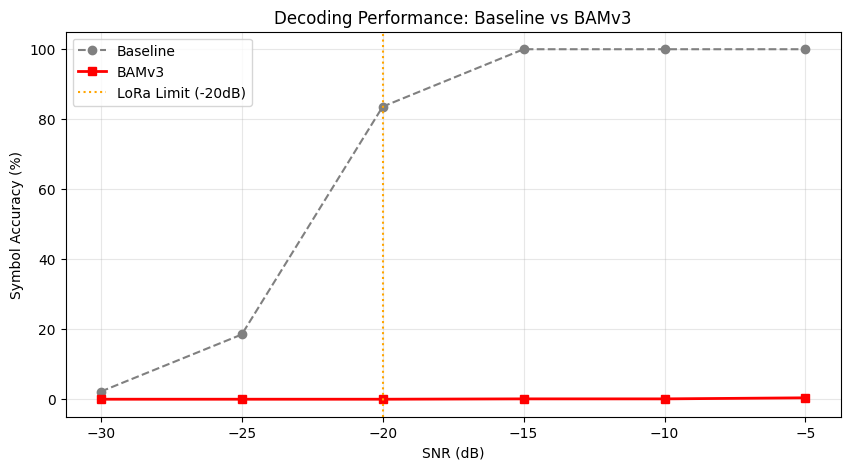

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- micro metric 준비 (sklearn 있으면 그걸 쓰고, 없으면 fallback) ---
try:
    from sklearn.metrics import accuracy_score, fbeta_score

    def micro_metrics(y_true, y_pred):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Micro F0.5": fbeta_score(y_true, y_pred, beta=0.5, average="micro"),
            "Micro F1":   fbeta_score(y_true, y_pred, beta=1.0, average="micro"),
            "Micro F2":   fbeta_score(y_true, y_pred, beta=2.0, average="micro"),
            "Micro F3":   fbeta_score(y_true, y_pred, beta=3.0, average="micro"),
        }
except Exception:
    # fallback: micro는 단일 라벨 분류에서 "전체 TP/FP/FN" 기준
    # 다중클래스 single-label에서는 micro Fβ가 사실상 accuracy와 같아지는 경우가 많음.
    def micro_metrics(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        acc = float(np.mean(y_true == y_pred))
        return {"Accuracy": acc, "Micro F0.5": acc, "Micro F1": acc, "Micro F2": acc, "Micro F3": acc}


print("\n" + "="*70)
print("📊 QUANTITATIVE PERFORMANCE EVALUATION (Baseline vs BAM)")
print("="*70)

NUM_TEST_SAMPLES = 1000
TEST_SNR_LEVELS = [-30, -25, -20, -15, -10, -5]

results = {
    snr: {
        # sample-wise 저장 (micro 계산용)
        "y_true": [],
        "y_pred_base": [],
        "y_pred_bam": [],

        # 기타 통계(참고)
        "bam_mse": [],
        "bam_peak_ratio": [],
        "base_peak_ratio": [],

        "errors": 0,   # 예외 발생 건수
    }
    for snr in TEST_SNR_LEVELS
}

print(f"\n🧪 Testing with {NUM_TEST_SAMPLES} samples at each SNR level...")
print(f"SNR levels: {TEST_SNR_LEVELS} dB\n")

for snr in TEST_SNR_LEVELS:
    print(f"\n{'─'*70}")
    print(f"Testing SNR = {snr} dB")
    print(f"{'─'*70}")

    for i in range(NUM_TEST_SAMPLES):
        try:
            test_sym = np.random.randint(0, 512)

            clean_iq_test = X_clean_iq[test_sym]
            noisy_iq_test = lora.awgn_iq(clean_iq_test, snr)

            # 1) noisy -> flat + params
            noisy_flat, noisy_params = generate_complex_spectrogram(noisy_iq_test, fs, bw)

            # 2) BAM 복원
            compressed = model.compress(noisy_flat.reshape(1, -1))
            restored_flat = model.decompress(compressed).flatten()

            # 3) IQ 재구성 (✅ fs 인자 제거: 새 함수 시그니처)
            iq_restored = reconstruct_iq_from_spectrogram(restored_flat, noisy_params)

            # 4) 길이 보정 (trim/pad만)
            target_len = len(clean_iq_test)
            cur_len = len(iq_restored)

            if cur_len != target_len:
                if cur_len > target_len:
                    diff = cur_len - target_len
                    start = diff // 2
                    iq_restored = iq_restored[start:start + target_len]
                else:
                    diff = target_len - cur_len
                    pad_left = diff // 2
                    pad_right = diff - pad_left
                    iq_restored = np.pad(iq_restored, (pad_left, pad_right), mode="constant", constant_values=0)

            # 5) (선택) power 정규화: unit power
            power = np.mean(np.abs(iq_restored) ** 2)
            if power > 1e-12:
                iq_restored = iq_restored / np.sqrt(power)

            # 6) 디코드
            code_base, peak_base = estimate_symbol_custom(noisy_iq_test, sf, fs, bw)
            code_bam,  peak_bam  = estimate_symbol_custom(iq_restored,   sf, fs, bw)

            # clean peak은 ratio 기준선(참고)
            _, peak_clean = estimate_symbol_custom(clean_iq_test, sf, fs, bw)

            # 7) 저장(✅ micro용)
            results[snr]["y_true"].append(int(test_sym))
            results[snr]["y_pred_base"].append(int(code_base))
            results[snr]["y_pred_bam"].append(int(code_bam))

            # 8) Peak ratio (참고)
            if peak_clean > 0:
                results[snr]["base_peak_ratio"].append(float(peak_base / peak_clean))
                results[snr]["bam_peak_ratio"].append(float(peak_bam / peak_clean))

            # 9) MSE (참고)
            mse = float(np.mean(np.abs(iq_restored - clean_iq_test) ** 2))
            results[snr]["bam_mse"].append(mse)

        except Exception as e:
            results[snr]["errors"] += 1
            # 너무 많이 찍히면 출력이 터지니까 처음 몇 개만 보여줌
            if results[snr]["errors"] <= 5:
                print(f"  ⚠️ Error at sample {i}: {e}")
            continue

    # --- SNR별 중간 출력(micro) ---
    y_true = results[snr]["y_true"]
    yb = results[snr]["y_pred_base"]
    ym = results[snr]["y_pred_bam"]

    base_m = micro_metrics(y_true, yb) if len(y_true) else {"Accuracy": 0, "Micro F0.5":0, "Micro F1":0, "Micro F2":0, "Micro F3":0}
    bam_m  = micro_metrics(y_true, ym) if len(y_true) else {"Accuracy": 0, "Micro F0.5":0, "Micro F1":0, "Micro F2":0, "Micro F3":0}

    print(f"  ✓ Valid samples : {len(y_true)}/{NUM_TEST_SAMPLES}  (errors={results[snr]['errors']})")
    print(f"  ✓ Baseline Acc  : {base_m['Accuracy']*100:.1f}% | MicroF1: {base_m['Micro F1']*100:.1f}%")
    print(f"  ✓ BAM Acc       : {bam_m['Accuracy']*100:.1f}% | MicroF1: {bam_m['Micro F1']*100:.1f}%")

# --- 최종 요약: 교수님 요구 지표 포함 ---
print("\n" + "="*70)
print("📈 FINAL RESULTS SUMMARY (Accuracy + Micro F-beta)")
print("="*70)

header = f"{'SNR':<6} | {'BaseAcc':>7} {'BAMAcc':>7} | {'μF0.5':>7} {'μF1':>7} {'μF2':>7} {'μF3':>7} | {'μF0.5':>7} {'μF1':>7} {'μF2':>7} {'μF3':>7} | {'Err':>4}"
print(header)
print("─"*len(header))

summary_base_acc = []
summary_bam_acc = []

for snr in TEST_SNR_LEVELS:
    y_true = results[snr]["y_true"]
    yb = results[snr]["y_pred_base"]
    ym = results[snr]["y_pred_bam"]

    base_m = micro_metrics(y_true, yb) if len(y_true) else {"Accuracy": 0, "Micro F0.5":0, "Micro F1":0, "Micro F2":0, "Micro F3":0}
    bam_m  = micro_metrics(y_true, ym) if len(y_true) else {"Accuracy": 0, "Micro F0.5":0, "Micro F1":0, "Micro F2":0, "Micro F3":0}

    summary_base_acc.append(base_m["Accuracy"]*100)
    summary_bam_acc.append(bam_m["Accuracy"]*100)

    print(
        f"{snr:<6} | "
        f"{base_m['Accuracy']*100:7.1f} {bam_m['Accuracy']*100:7.1f} | "
        f"{base_m['Micro F0.5']*100:7.1f} {base_m['Micro F1']*100:7.1f} {base_m['Micro F2']*100:7.1f} {base_m['Micro F3']*100:7.1f} | "
        f"{bam_m['Micro F0.5']*100:7.1f} {bam_m['Micro F1']*100:7.1f} {bam_m['Micro F2']*100:7.1f} {bam_m['Micro F3']*100:7.1f} | "
        f"{results[snr]['errors']:4d}"
    )

# --- 그래프(Accuracy만) ---
plt.figure(figsize=(10, 5))
plt.plot(TEST_SNR_LEVELS, summary_base_acc, 'o--', label='Baseline', color='gray')
plt.plot(TEST_SNR_LEVELS, summary_bam_acc, 's-', label='BAMv3', color='red', linewidth=2)
plt.axvline(x=-20, color='orange', linestyle=':', label='LoRa Limit (-20dB)')
plt.xlabel('SNR (dB)')
plt.ylabel('Symbol Accuracy (%)')
plt.title('Decoding Performance: Baseline vs BAMv3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
from sklearn.metrics import accuracy_score, fbeta_score

def micro_scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Micro F0.5": fbeta_score(y_true, y_pred, beta=0.5, average="micro"),
        "Micro F1":   fbeta_score(y_true, y_pred, beta=1.0, average="micro"),
        "Micro F2":   fbeta_score(y_true, y_pred, beta=2.0, average="micro"),
        "Micro F3":   fbeta_score(y_true, y_pred, beta=3.0, average="micro"),
    }
